# simple linear regreation

In [ ]:
###simple linear regreatiomn
#jodi akta independent variable thake tahole amra seta k simple linear regreation boli,,
#যখন ১টা independent variable (X) দিয়ে ১টা dependent variable (Y) predict করা হয়—তখন তাকে Simple Linear Regression বলে।
###Multilpe linear regteation 
#যখন ২টা বা তার বেশি independent variable (X₁, X₂, X₃ …) দিয়ে ১টা dependent variable (Y) predict করা হয়—তখন তাকে Multiple Linear Regression বলে।

In [ ]:
### dependent variable k target bola hoye thake
### independent variable k feature bola hoye thake
###ডেটার সব পয়েন্টের মাঝ দিয়ে অনেক লাইন টানা যায়।কিন্তু যে লাইনে prediction error সবচেয়ে কম হয়,সেই লাইনটাই হলো best fitting line।

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.chdir("C:/Users/arman/ostad_code")

In [6]:
df=pd.read_csv("student_marks.csv")
df

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19
...,...,...
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05


In [3]:
df.describe()

,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


##prepare the data for machine learning algorithm

data cleaning

In [5]:
df.isna().sum()

study_hours      5
student_marks    0
dtype: int64

In [6]:
mn=df.study_hours.mean()
mn

np.float64(6.9959487179487185)

In [7]:
df2=df.fillna(mn)
df2

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19
...,...,...
195,7.530000,81.67
196,8.560000,84.68
197,8.940000,86.75
198,6.600000,78.05


In [10]:
df2.isna().sum()

study_hours      0
student_marks    0
dtype: int64

## data visualization kore dakbo ata kmn data ,ar outlier ase naki

Text(0.5, 1.0, 'scatter plot of Students study hours and Students marks')

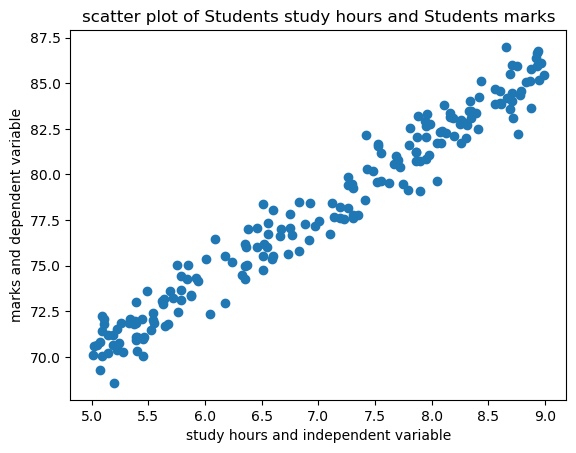

In [12]:
plt.scatter(df.study_hours,df.student_marks)
plt.xlabel("study hours and independent variable")
plt.ylabel("marks and dependent variable")
plt.title("scatter plot of Students study hours and Students marks")
##akane outlier thakle kesu dot dure dure thakto

In [13]:
df2

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19
...,...,...
195,7.530000,81.67
196,8.560000,84.68
197,8.940000,86.75
198,6.600000,78.05


#splite data set

### train_test_splite korbo akn,,mane train data ar test datai vg korte hbe

In [14]:
x=df2[["study_hours"]]
x

,study_hours
0,6.830000
1,6.560000
2,6.995949
3,5.670000
4,8.670000
...,...
195,7.530000
196,8.560000
197,8.940000
198,6.600000


In [17]:
y=df2[["student_marks"]]
y

,student_marks
0,78.50
1,76.74
2,78.68
3,71.82
4,84.19
...,...
195,81.67
196,84.68
197,86.75
198,78.05


In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=3)

In [23]:
x_train


,study_hours
156,8.39
115,5.79
155,5.14
15,6.55
61,7.26
...,...
0,6.83
184,5.22
131,5.26
152,8.08


In [24]:
x_test

,study_hours
40,5.280000
51,7.310000
139,8.600000
197,8.940000
170,5.190000
82,6.660000
183,8.610000
46,7.010000
70,5.370000
100,6.240000


In [25]:
x_test.count()

study_hours    40
dtype: int64

In [26]:
y_train

,student_marks
156,83.37
115,74.44
155,70.20
15,76.03
61,79.41
...,...
0,78.50
184,71.50
131,71.86
152,81.70


In [27]:
y_test

,student_marks
40,70.27
51,77.77
139,83.91
197,86.75
170,71.18
82,76.63
183,83.87
46,77.46
70,71.80
100,75.18


In [28]:
y_test.count()

student_marks    40
dtype: int64

## model train korbo akn

In [ ]:
#আমরা জানি Simple Linear Regression এর সূত্র👇

#📌 Y = mX + c

#এখানে m = slope, c = intercept

#uporer oi sutro ta deye linear regression bar kora hoye thake,
📌 Y = mX + c — ব্যাখ্যা
🔹 Y

👉 যেটা আমরা predict করতে চাই
👉 একে বলে Dependent Variable

🔹 X

👉 যেটার উপর Y depend করে
👉 একে বলে Independent Variable

🔹 m (Slope)

👉 X ১ ইউনিট বাড়লে Y কত পরিবর্তন হবে তা বোঝায়

m positive → X বাড়লে Y বাড়ে

m negative → X বাড়লে Y কমে

🔹 c (Intercept)

👉 যখন X = 0, তখন Y এর মান কত
👉 গ্রাফে Y-axis এ line যেখানে কাটে

In [32]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
#fit mathod ar maddome ota kaj kore thake,,
#slop ar intercept bar kore thake fit ar madome,,

LinearRegression()

In [33]:
lr.coef_
#co efeciant,,,ar maddome slop dakhe

array([[3.87141669]])

In [34]:
lr.intercept_
#ar maddome intercept deha hoy

array([50.83451149])

In [35]:
##slop ar intercept paile Y = mX + c ai sutro deye linear regression bar kora jai,,
#but onk bar korte hole amra method use korbo nise

In [38]:
lr.predict([[5.28]])

C:\Users\arman\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[71.27559163]])

In [43]:
prediction=lr.predict(x_test)
prediction

array([[71.27559163],
       [79.13456752],
       [84.12869505],
       [85.44497673],
       [70.92716412],
       [76.61814666],
       [84.16740922],
       [77.97314251],
       [71.62401913],
       [74.99215165],
       [78.94099668],
       [74.10172581],
       [81.65098837],
       [73.25001414],
       [81.2638467 ],
       [71.04330663],
       [74.41143915],
       [72.78544414],
       [85.36754839],
       [71.70144746],
       [82.54141421],
       [76.03743416],
       [80.83799086],
       [76.65686083],
       [84.36098005],
       [79.09585335],
       [75.53414999],
       [77.91874414],
       [81.6122742 ],
       [73.59844164],
       [85.21269172],
       [70.23030912],
       [79.98627919],
       [84.59326505],
       [72.5918733 ],
       [83.97383838],
       [84.39969422],
       [75.41800749],
       [82.81241337],
       [85.48369089]])

In [44]:
hj=np.c_[x_test,y_test,prediction]
hj
#akane numpy ar dara concatanation kora hoyse

array([[ 5.28      , 70.27      , 71.27559163],
       [ 7.31      , 77.77      , 79.13456752],
       [ 8.6       , 83.91      , 84.12869505],
       [ 8.94      , 86.75      , 85.44497673],
       [ 5.19      , 71.18      , 70.92716412],
       [ 6.66      , 76.63      , 76.61814666],
       [ 8.61      , 83.87      , 84.16740922],
       [ 7.01      , 77.46      , 77.97314251],
       [ 5.37      , 71.8       , 71.62401913],
       [ 6.24      , 75.18      , 74.99215165],
       [ 7.26      , 78.17      , 78.94099668],
       [ 6.01      , 75.36      , 74.10172581],
       [ 7.96      , 83.33      , 81.65098837],
       [ 5.79      , 73.14      , 73.25001414],
       [ 7.86      , 80.72      , 81.2638467 ],
       [ 5.22      , 70.4       , 71.04330663],
       [ 6.09      , 76.48      , 74.41143915],
       [ 5.67      , 71.82      , 72.78544414],
       [ 8.92      , 86.41      , 85.36754839],
       [ 5.39      , 70.9       , 71.70144746],
       [ 8.19      , 83.08      , 82.541

In [45]:
ge=pd.DataFrame(data=hj,columns=["study hours","marks orginal","marks predicted"])
ge

,study hours,marks orginal,marks predicted
0,5.280000,70.27,71.275592
1,7.310000,77.77,79.134568
2,8.600000,83.91,84.128695
3,8.940000,86.75,85.444977
4,5.190000,71.18,70.927164
5,6.660000,76.63,76.618147
6,8.610000,83.87,84.167409
7,7.010000,77.46,77.973143
8,5.370000,71.80,71.624019
9,6.240000,75.18,74.992152


# Model Accuracy test

In [46]:
lr.score(x_test,y_test)

0.9645118422627414

In [47]:
#96% accuracy ase amr model tar